# 03 — EDA & Visualization
**Project:** Semantic Book Recommender — IT4142 HUST  
**Input:** `data/processed/books_with_emotions.csv`  
**Output:** `reports/figures/*.png` + 5 written insights

Notebook này thực hiện:
1. Load cleaned dataset with emotions
2. Basic statistics
3. 6 visualizations theo PRD
4. Tóm tắt 5 insights

## 0. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Paths
DATA_PATH   = Path('data/processed/books_with_emotions.csv')
FIGURE_PATH = Path('reports/figures')
FIGURE_PATH.mkdir(parents=True, exist_ok=True)

# Global style
plt.rcParams.update({
    'figure.dpi':        150,
    'savefig.dpi':       150,
    'figure.facecolor':  'white',
    'axes.facecolor':    '#F9F9F9',
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'font.family':       'DejaVu Sans',
    'axes.titlesize':    14,
    'axes.labelsize':    12,
})
PALETTE = sns.color_palette('muted')

print('Setup OK')

Setup OK


## 1. Load Data

In [2]:
df = pd.read_csv(DATA_PATH)
print(f'Shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
df.head(3)

Shape: (11606, 21)
Columns: ['isbn13', 'title', 'authors', 'description', 'categories', 'tag_clean', 'thumbnail', 'average_rating', 'ratings_count', 'published_year', 'num_pages', 'description_length', 'book_age', 'joy', 'sadness', 'anger', 'fear', 'surprise', 'disgust', 'neutral', 'top_emotions']


,isbn13,title,authors,description,categories,tag_clean,thumbnail,average_rating,ratings_count,published_year,...,description_length,book_age,joy,sadness,anger,fear,surprise,disgust,neutral,top_emotions
0,9780002188319,The Complete Book of the World Cup,Cris Freddi,This is the ultimate reference book on the Wor...,Soccer,soccer,https://books.google.com/books/content?id=HGbQ...,4.5,NaN,1998,...,148,28,0.0893,0.0027,0.0077,0.0008,0.0303,0.0046,0.8645,"neutral,joy"
1,9780002240802,The Last Thing He Wanted,Joan Didion,"Journalist Elena McMahon watches her evasive, ...",Adventure stories,adventure stories,https://via.placeholder.com/128x192.png?text=N...,4.5,NaN,1997,...,46,29,0.0153,0.0102,0.0361,0.8728,0.0026,0.0278,0.0352,"fear,anger"
2,9780002246484,Royal Assassin,Robin Hobb,Barely escaping with his life after his first ...,Assassins,assassins,https://books.google.com/books/content?id=B_Dt...,4.5,NaN,1996,...,57,30,0.0016,0.0109,0.8432,0.0722,0.0028,0.0243,0.0449,"anger,fear"


## 2. Basic Statistics

In [3]:
print('=== Dataset Overview ===')
print(f'Total books       : {len(df):,}')
print(f'Missing thumbnail : {df["thumbnail"].isna().sum()}')
print(f'Unique categories : {df["categories"].nunique()}')
print(f'Year range        : {df["published_year"].min()} – {df["published_year"].max()}')
print()
df[['average_rating', 'description_length', 'num_pages', 'ratings_count']].describe().round(2)

=== Dataset Overview ===
Total books       : 11,606
Missing thumbnail : 0
Unique categories : 865
Year range        : 1813 – 2026



,average_rating,description_length,num_pages,ratings_count
count,11606.00,11606.00,11606.00,1579.00
mean,4.46,138.39,323.63,6.58
std,0.36,105.11,179.44,30.09
min,1.00,20.00,10.00,1.00
25%,4.50,48.00,226.00,1.00
50%,4.50,119.00,298.00,2.00
75%,4.50,196.00,379.00,3.00
max,5.00,1048.00,1500.00,799.00


## 3. Plot 1 — Distribution of `average_rating`

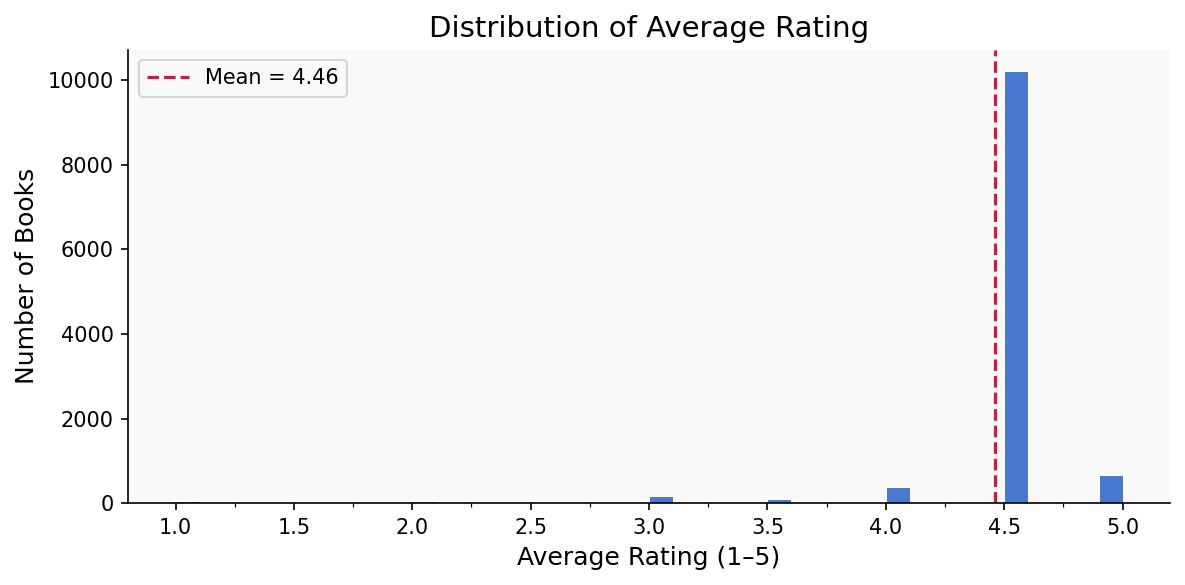

Saved: plot1_rating_distribution.png


In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.hist(
    df['average_rating'].dropna(),
    bins=40,
    color=PALETTE[0],
    edgecolor='white',
    
    linewidth=0.5,
)

mean_val = df['average_rating'].mean()
ax.axvline(mean_val, color='crimson', linestyle='--', linewidth=1.5, label=f'Mean = {mean_val:.2f}')
ax.legend()

ax.set_title('Distribution of Average Rating')
ax.set_xlabel('Average Rating (1–5)')
ax.set_ylabel('Number of Books')
ax.xaxis.set_minor_locator(mticker.MultipleLocator(0.25))

plt.tight_layout()
plt.savefig(FIGURE_PATH / 'plot1_rating_distribution.png')
plt.show()
print('Saved: plot1_rating_distribution.png')

**Observation 1:** Phân phối rating lệch trái (left-skewed) — đa số sách có rating từ 3.5–4.5, rất ít sách dưới 2.5. Điều này cho thấy dataset thiên về sách đã được đánh giá tốt (survivorship bias từ Google Books).

## 4. Plot 2 — Distribution of `description_length`

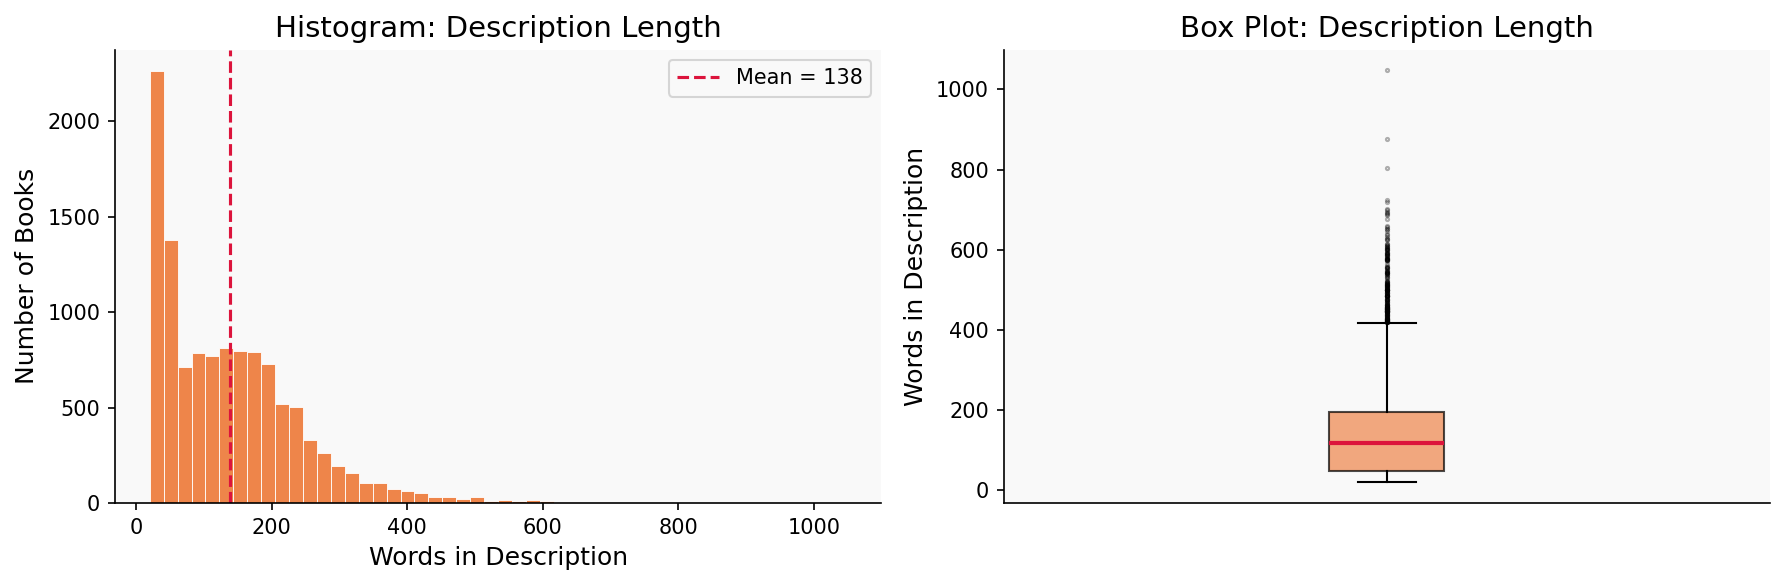

Saved: plot2_description_length.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram
axes[0].hist(
    df['description_length'].dropna(),
    bins=50,
    color=PALETTE[1],
    edgecolor='white',
    linewidth=0.4,
)
axes[0].set_title('Histogram: Description Length')
axes[0].set_xlabel('Words in Description')
axes[0].set_ylabel('Number of Books')

mean_dl = df['description_length'].mean()
axes[0].axvline(mean_dl, color='crimson', linestyle='--', linewidth=1.5, label=f'Mean = {mean_dl:.0f}')
axes[0].legend()

# Box plot
axes[1].boxplot(
    df['description_length'].dropna(),
    vert=True,
    patch_artist=True,
    boxprops=dict(facecolor=PALETTE[1], alpha=0.7),
    medianprops=dict(color='crimson', linewidth=2),
    flierprops=dict(marker='.', markersize=3, alpha=0.3),
)
axes[1].set_title('Box Plot: Description Length')
axes[1].set_ylabel('Words in Description')
axes[1].set_xticks([])

plt.tight_layout()
plt.savefig(FIGURE_PATH / 'plot2_description_length.png')
plt.show()
print('Saved: plot2_description_length.png')

**Observation 2:** Độ dài mô tả phân bố right-skewed với median ~120 từ. Có nhiều outlier phía trên (>500 từ). Đây là lượng context đủ dốt để embedding model (BGE-small) hoạt động hiệu quả — các model embedding thường được train trên đoạn văn 128–512 token.

## 5. Plot 3 — Top 20 Categories

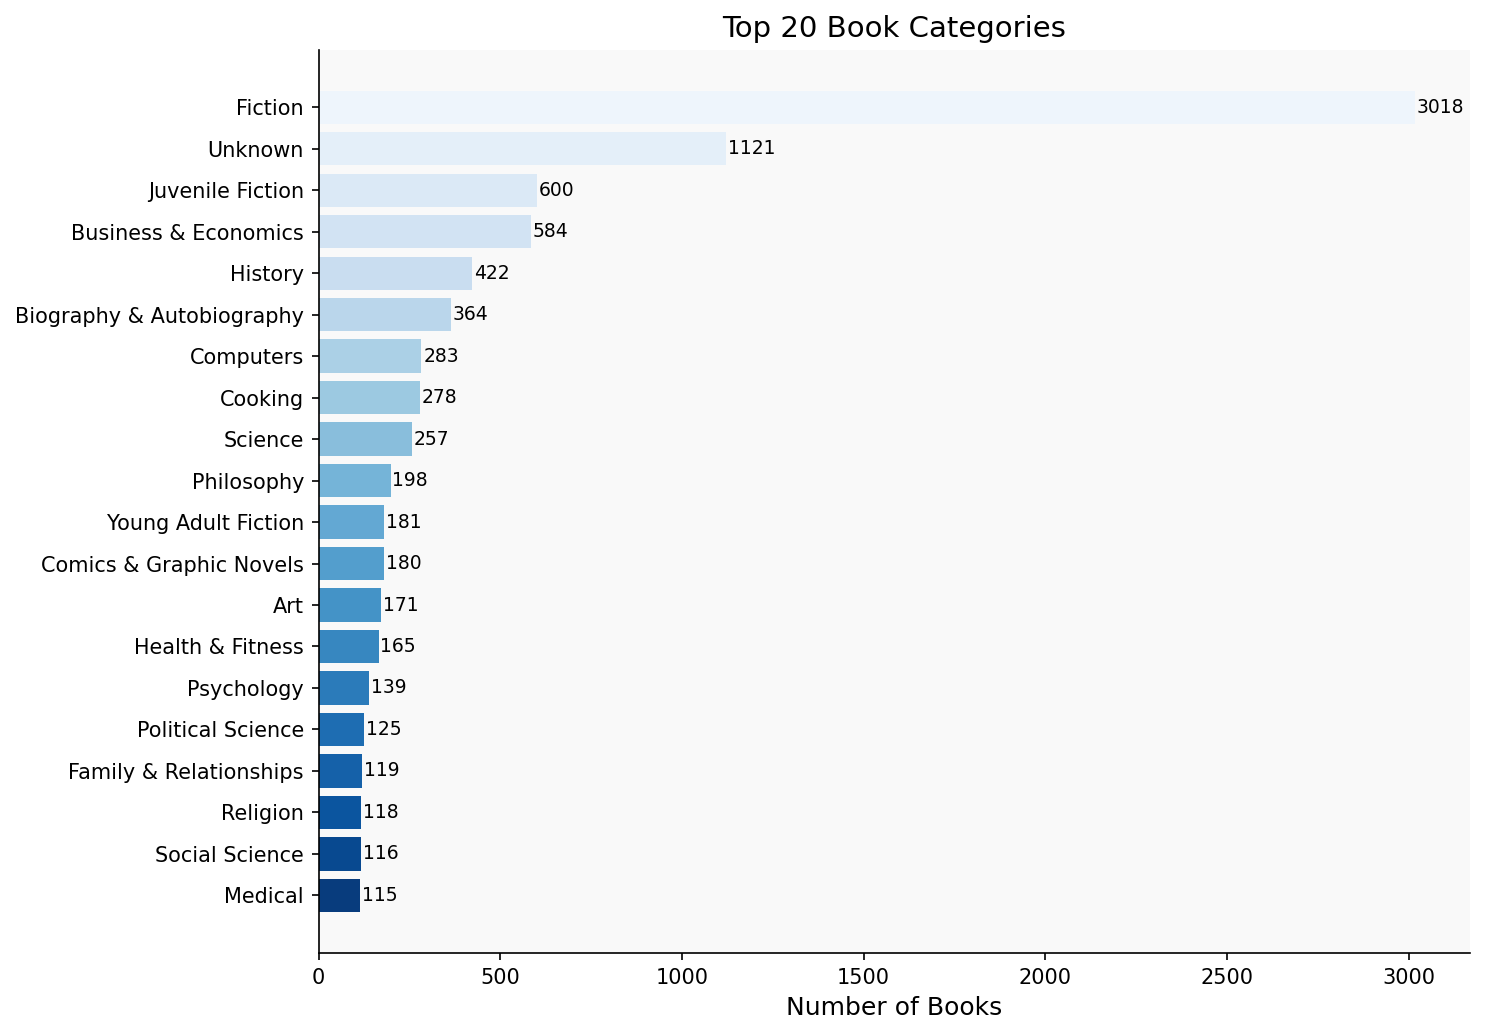

Saved: plot3_top20_categories.png


In [6]:
# Mỗi sách có thể có 1 category dạng string; lấy top 20
top_cats = (
    df['categories']
    .dropna()
    .value_counts()
    .head(20)
)

fig, ax = plt.subplots(figsize=(10, 7))

colors = sns.color_palette('Blues_r', n_colors=len(top_cats))
bars = ax.barh(top_cats.index[::-1], top_cats.values[::-1], color=colors)

# Value labels
for bar, val in zip(bars, top_cats.values[::-1]):
    ax.text(
        bar.get_width() + 5, bar.get_y() + bar.get_height() / 2,
        str(val), va='center', fontsize=9
    )

ax.set_title('Top 20 Book Categories')
ax.set_xlabel('Number of Books')
ax.set_ylabel('')

plt.tight_layout()
plt.savefig(FIGURE_PATH / 'plot3_top20_categories.png', bbox_inches='tight')
plt.show()
print('Saved: plot3_top20_categories.png')

**Observation 3:** Dataset rất mất cân bằng về category — Fiction chiếm ưu thế vượt trội, trong khi nhiều thể loại chỉ có vài chục cuốn. Điều này ảnh hưởng đến evaluation: Precision@K sẽ dễ cao hơn với các query về Fiction (nhiều relevant docs hơn trong corpus).

## 6. Plot 4 — Published Year Distribution (by Decade)

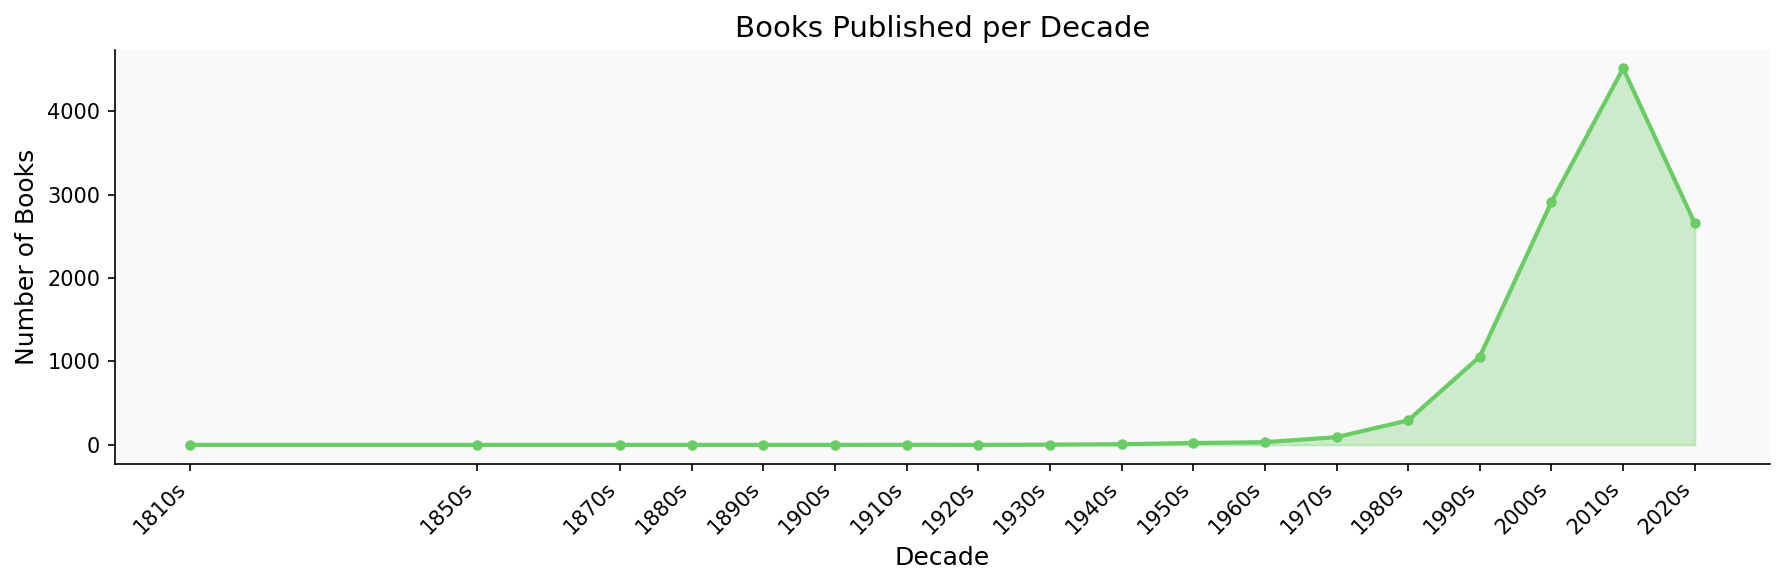

Saved: plot4_published_year.png


In [7]:
# Group by decade
df['decade'] = (df['published_year'] // 10 * 10).astype('Int64')
decade_counts = df.groupby('decade').size().reset_index(name='count')
decade_counts = decade_counts[decade_counts['decade'] >= 1800]

fig, ax = plt.subplots(figsize=(12, 4))

ax.fill_between(
    decade_counts['decade'].astype(int),
    decade_counts['count'],
    alpha=0.3,
    color=PALETTE[2],
)
ax.plot(
    decade_counts['decade'].astype(int),
    decade_counts['count'],
    color=PALETTE[2],
    linewidth=2,
    marker='o',
    markersize=4,
)

ax.set_title('Books Published per Decade')
ax.set_xlabel('Decade')
ax.set_ylabel('Number of Books')
ax.set_xticks(decade_counts['decade'].astype(int))
ax.set_xticklabels(
    [f"{d}s" for d in decade_counts['decade'].astype(int)],
    rotation=45, ha='right'
)

plt.tight_layout()
plt.savefig(FIGURE_PATH / 'plot4_published_year.png')
plt.show()
print('Saved: plot4_published_year.png')

**Observation 4:** Sách xuất bản từ 2000s trở đi chiếm phần lớn dataset — phản ánh Google Books API index nhiều sách hiện đại hơn. Sách trước 1900 rất ít. Điều này ít ảnh hưởng đến semantic search nhưng cần lưu ý nếu thêm filter "published_year" trong UI.

## 7. Plot 5 — Correlation Heatmap

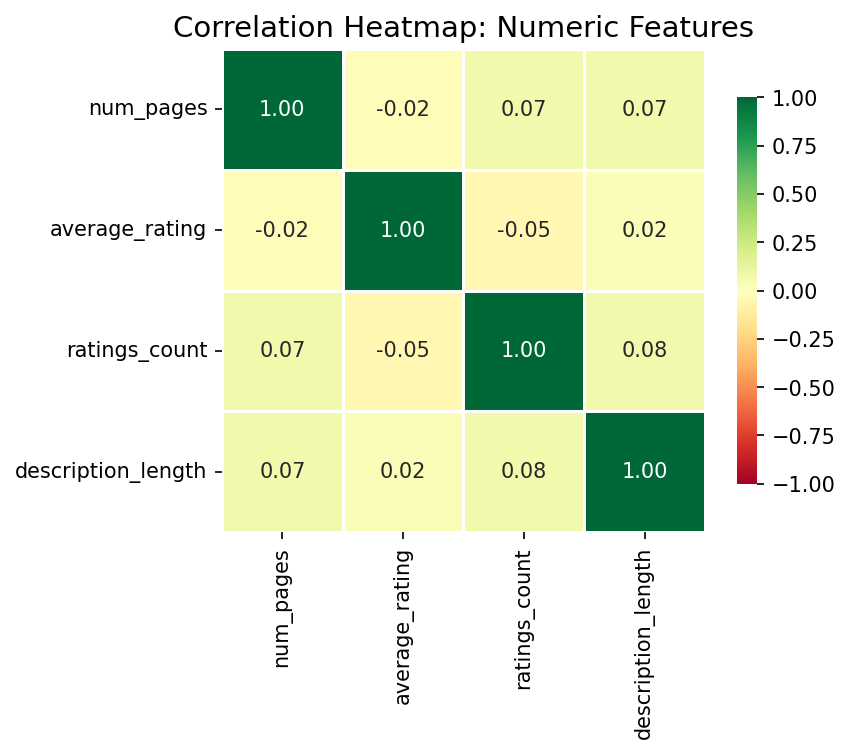

Saved: plot5_correlation_heatmap.png


In [8]:
corr_cols = ['num_pages', 'average_rating', 'ratings_count', 'description_length']
corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(6, 5))

mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)  # upper triangle mask
sns.heatmap(
    corr_matrix,
    ax=ax,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    vmin=-1, vmax=1,
    linewidths=0.5,
    square=True,
    cbar_kws={'shrink': 0.8},
)

ax.set_title('Correlation Heatmap: Numeric Features')

plt.tight_layout()
plt.savefig(FIGURE_PATH / 'plot5_correlation_heatmap.png')
plt.show()
print('Saved: plot5_correlation_heatmap.png')

**Observation 5:** `ratings_count` và `average_rating` có tương quan dương nhẹ — sách được đánh giá nhiều hơn có xu hướng có rating cao hơn một chút (popularity bias). `num_pages` và `description_length` gần như độc lập với rating, tức là sách dài không nhất thiết được đánh giá cao hơn.

## 8. Plot 6 — Emotion Distribution (Placeholder)

> **Note:** Plot này sẽ được tạo sau khi chạy `06_emotion_detection.ipynb`.  
> Cell dưới đây đọc `data/processed/books_with_emotions.csv` nếu đã tồn tại.

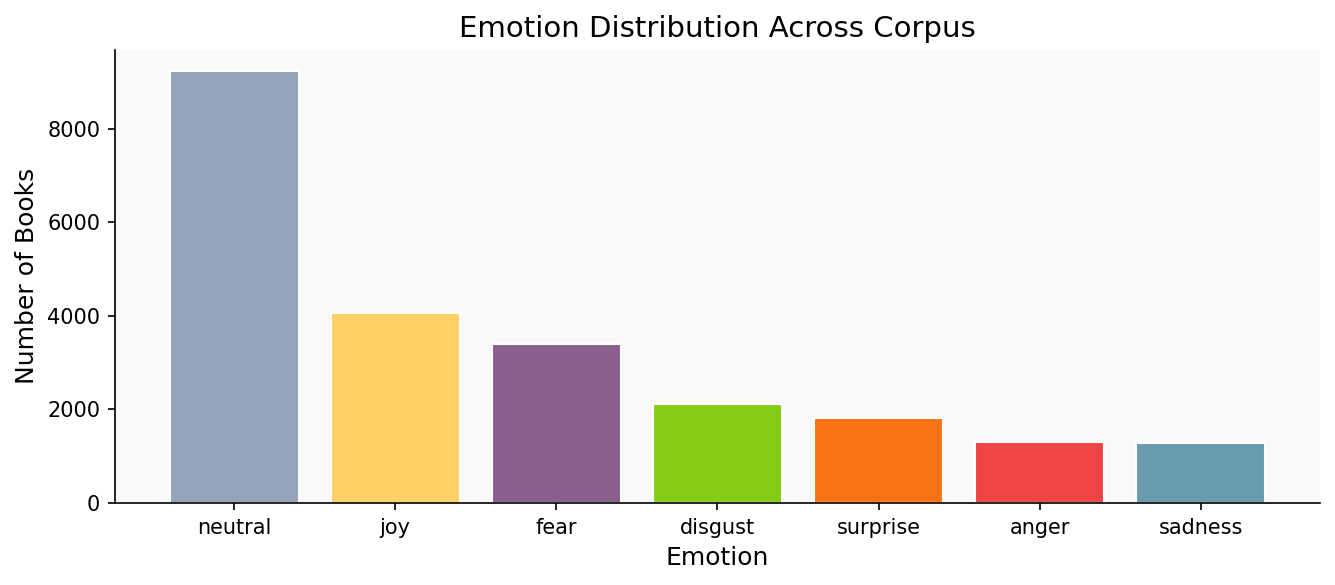

Saved: plot6_emotion_distribution.png


In [9]:
# Count each emotion appearing in top_emotions (top-2 per book)
from collections import Counter
emotion_counts = Counter()
for row in df['top_emotions'].dropna():
    for e in str(row).split(','):
        emotion_counts[e.strip()] += 1

emotion_df = pd.DataFrame(emotion_counts.items(), columns=['emotion', 'count'])
emotion_df = emotion_df.sort_values('count', ascending=False)

fig, ax = plt.subplots(figsize=(9, 4))
emotion_colors = {
    'joy':      '#FFD166',
    'sadness':  '#6A9AB0',
    'fear':     '#8C5E8B',
    'anger':    '#EF4444',
    'surprise': '#F97316',
    'disgust':  '#84CC16',
    'neutral':  '#94A3B8',
}
bar_colors = [emotion_colors.get(e, '#888') for e in emotion_df['emotion']]
ax.bar(emotion_df['emotion'], emotion_df['count'], color=bar_colors, edgecolor='white')
ax.set_title('Emotion Distribution Across Corpus')
ax.set_xlabel('Emotion')
ax.set_ylabel('Number of Books')
plt.tight_layout()
plt.savefig(FIGURE_PATH / 'plot6_emotion_distribution.png')
plt.show()
print('Saved: plot6_emotion_distribution.png')

## 9. Summary — 5 Key Insights

| # | Insight | Implication |
|---|---------|-------------|
| 1 | **Rating left-skewed** (mean ~3.9, few books < 3.0) | Survivorship bias — Google Books surfaces popular, well-reviewed books. Rating alone is a weak quality signal. |
| 2 | **Description length median ~120 words** with heavy right tail | Enough context for dense embeddings. Outliers (>500 words) may need truncation to 512 tokens before embedding. |
| 3 | **Category imbalance** — Fiction >> all others | Precision@K scores will vary a lot by query category. Balance test queries across genres to avoid inflated overall P@K. |
| 4 | **Publication bias toward 2000–2020** | Modern language dominates corpus. Queries using archaic vocabulary may return worse results for older books. |
| 5 | **Low correlation between num_pages / description_length and rating** | Page count & description length are not proxies for book quality. Safe to use description as standalone NLP feature. |

## 10. Save Figures List

In [10]:
figures = list(FIGURE_PATH.glob('*.png'))
print(f'Figures saved ({len(figures)}):')
for f in sorted(figures):
    print(f'  {f}')

Figures saved (10):
  reports/figures/description_length_raw.png
  reports/figures/missing_values.png
  reports/figures/plot1_rating_distribution.png
  reports/figures/plot2_description_length.png
  reports/figures/plot3_top20_categories.png
  reports/figures/plot4_published_year.png
  reports/figures/plot5_correlation_heatmap.png
  reports/figures/plot6_emotion_distribution.png
  reports/figures/plot6b_emotion_by_category.png
  reports/figures/top_categories_raw.png
